# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Tay Jing Wen



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [20]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly
import joblib

# 1. Business Understanding
Goal: to predict whether the person will get a heart disease

# 2. Data Understanding

## 2.1 Load dataset

In [21]:
## Read *.csv file into pandas DataFrame
FILE_PATH = "heart_disease_uci.csv"
df = pd.read_csv(FILE_PATH) 
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


## 2.2 Summary Statistics

In [22]:
## Understand the type of variable for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


The dataset contains a mixture of numeric, categorical and boolean variables. Some columns have fewere non-null values than the t6otal number of rows, indicating that missing-value imputations is required before model-training.

In [23]:
## Check for missing data
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
exang        55
thalch       55
chol         30
restecg       2
dtype: int64

The results show that several numeric and categorical features contain missing values. Different strategies will be applied depending on whether the feature is numerical or categorical.

In [24]:
## Further feature engineering / feature selection

df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 40, 50, 60, 70, float("inf")],
    labels=[
        "Below 40",
        "40-49",
        "50-59",
        "60-69",
        "70 and above"
    ],
    right=False
)

df["chol_risk"] = pd.cut(
    df["chol"],
    bins=[0, 200, 240, float("inf")],
    labels=[
        "Normal",
        "Borderline",
        "High"
    ],
    include_lowest=True
)

categorical_columns = [
    "sex",
    "dataset",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "thal",
    "age_group",
    "chol_risk"
]

In [25]:
numeric_columns = [
    'age',
    'trestbps',
    'chol',
    'thalch',
    'oldpeak',
    'ca'
]

categorical_columns = [
    'sex',
    'dataset',
    'cp',
    'fbs',
    'restecg',
    'exang',
    'slope',
    'thal',
    'age_group',
    'chol_risk'
]

In [ ]:
#missing value treatment
df_clean = df.copy()

for col in numeric_columns:
    df_clean[col] = df_clean[col].fillna(
        df_clean[col].median()
    )

for col in categorical_columns:
    df_clean[col] = df_clean[col].fillna(
        df_clean[col].mode()[0]
    )

C:\Users\jingwen\AppData\Local\Temp\ipykernel_26600\588843966.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean[col] = df_clean[col].fillna(


Numerical missing values were replaced using median imputation because the median is less affected by extreme values. Categorical missing values were replaced using the most frequent value because categorical variables cannot be averaged.

In [27]:
## Describe data distribution
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


The patient ages vary across a wide range, and the clinical measurements such as cholesterol and resting blood pressure also show considerable variation. The minimum and maximum values should be examines for possible unusual or invalid measurements before training the models.

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

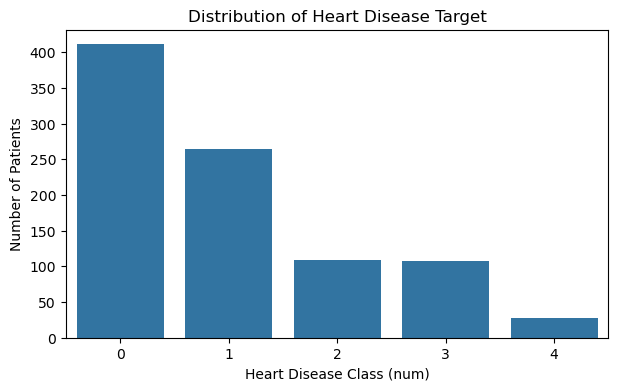

In [28]:
## Understanding distribution of target

plt.figure(figsize=(7, 4))
sns.countplot(x="num", data=df)
plt.title("Distribution of Heart Disease Target")
plt.xlabel("Heart Disease Class (num)")
plt.ylabel("Number of Patients")

plt.show()

The graph shows that the target contains five classes. Class 0 represents patients without heart disease, while Classes 1 to 4 represent patients with heart disease. Since the project focuses on detecting whether heart disease is present rather than predicting its severity, these classes will later be converted into a binary target. 

In [29]:
df["target"] = df["num"].apply(
    lambda x: 0 if x == 0 else 1
)

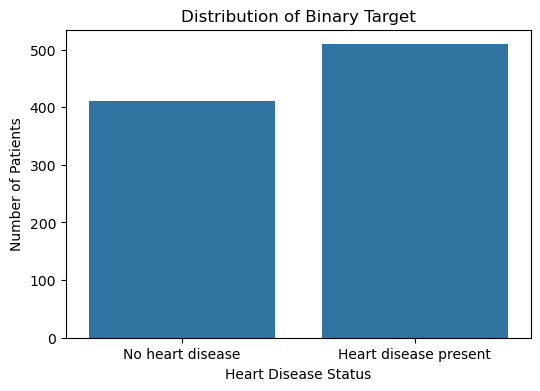

In [30]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="target")

plt.title("Distribution of Binary Target")
plt.xlabel("Heart Disease Status")
plt.ylabel("Number of Patients")
plt.xticks(ticks=[0, 1], labels=["No heart disease", "Heart disease present"])

plt.show()

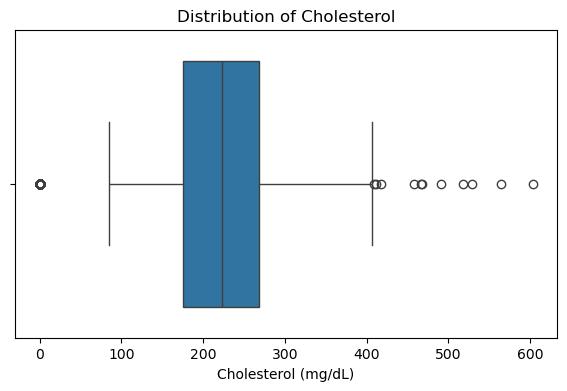

In [31]:
plt.figure(figsize=(7,4))
sns.boxplot(x=df["chol"])
plt.title("Distribution of Cholesterol")
plt.xlabel("Cholesterol (mg/dL)")
plt.show()

Boxplots were used to identify potential outliers in numerical features. Outliers were analysed to understand the distribution of the data before model training.

### 2.3.1.2 Understanding distribution of features

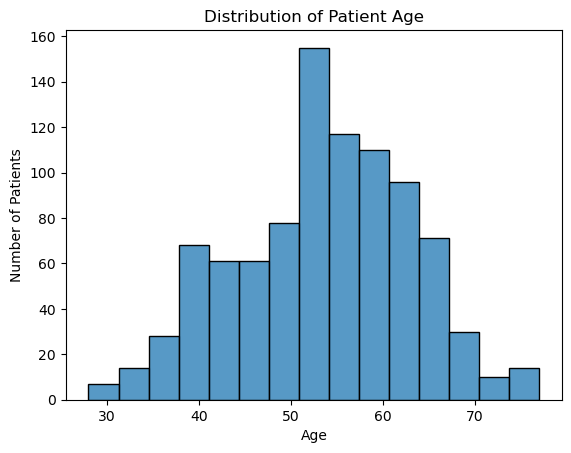

In [32]:
## Understanding distribution of features
sns.histplot(
    data=df,
    x="age",
    bins=15,
)

plt.title("Distribution of Patient Age")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()


The graph shows the age groups that are most strongly represented in the dataset. This is important because a model trained mainly on a certain age groups may perform less reliably for age groups with fewer observations

### 2.3.2 Understanding relationship between variables

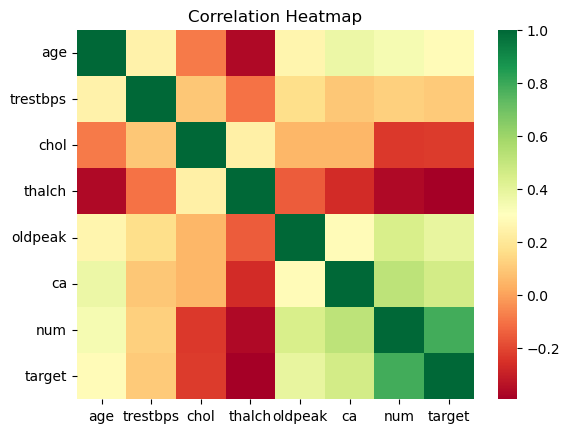

In [33]:
corr = df.drop(columns=["id"], errors="ignore").select_dtypes(include="number").corr()

sns.heatmap(corr, cmap='RdYlGn')

plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap was used to understand linear relationships between numerical variables. The 'id' column was excluded because it is only an identifier.

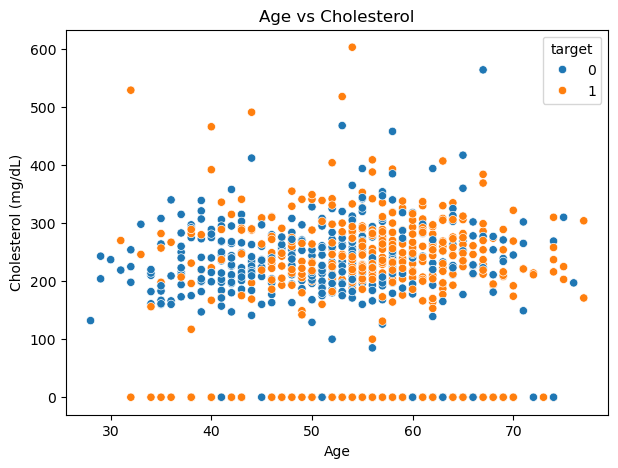

In [34]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x="age",
                y="chol",
                hue="target",
                data=df)

plt.title("Age vs Cholesterol")
plt.xlabel("Age")
plt.ylabel("Cholesterol (mg/dL)")
plt.show()

The two classes overlap across many age and cholesterol values. This suggests that age and cholesterol alone are unlikely to separate the classes perfectly, so the model shouldd consider multiple patient features together.

# 3. Data Preparation

## 3.1 Data Cleaning

In [35]:
## Clean data
df = df.drop(columns=['id'])
df['target'] = (df['num'] > 0).astype(int)
df

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,age_group,chol_risk,target
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,60-69,Borderline,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,60-69,High,1
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,60-69,Borderline,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,Below 40,High,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,40-49,Borderline,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1,50-59,High,1
916,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0,60-69,Normal,0
917,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2,50-59,Borderline,1
918,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0,50-59,High,0


The 'id' column was removed because it is only a unique identifier and does not provide meaningful information for predicting heart disease. 
The original target variable was converted into a binary classification target where 0 represents no heart disease and 1 represents heart disease. 

In [36]:
X = df.drop(['num', 'target'], axis=1)
y = df['target']

In [37]:
numeric_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

Categorical features:
['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'age_group', 'chol_risk']


## 3.2 Train-Test Split

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=2026,
    stratify=y
)

The dataset was split into training and testing sets using a 70:30 ratio. Stratification was applied to maintain same proportion of heart disease and non-heart disease cases in both sets. 

In [39]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="median")

X_train[numeric_features] = num_imputer.fit_transform(
    X_train[numeric_features]
)

X_test[numeric_features] = num_imputer.transform(
    X_test[numeric_features]
)

Median imputation was applied to numerical variables because the meidan is less affected by extreme values compared to the mean.

In [40]:
cat_imputer = SimpleImputer(strategy="most_frequent")

X_train[categorical_features] = cat_imputer.fit_transform(
    X_train[categorical_features]
)

X_test[categorical_features] = cat_imputer.transform(
    X_test[categorical_features]
)

Missing categorical values were replaces using the most frequent category because categorical variables cannot be averaged.

In [41]:
#OHE 
X_train = pd.get_dummies(
    X_train,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

X_test = pd.get_dummies(
    X_test,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

One-hot encoding was performed after train-test splitting to prevent information from the test set influencing the training process. The test dataset was then aligned with the training dataset to ensure both contain the same features.

In [42]:
print(X_train.shape)
print(X_test.shape)
print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())

(644, 27)
(276, 27)
0
0


# 4. Modelling

### 4.2 Train Model

In [43]:
from sklearn.linear_model import LogisticRegression

logr = LogisticRegression(
    max_iter=1000,
    random_state=2026
)

logr.fit(X_train, y_train)

c:\Users\jingwen\anaconda3\envs\mldp\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",2026
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [44]:
from sklearn.tree import DecisionTreeClassifier

# Initialise Decision Tree model
dt = DecisionTreeClassifier(
    random_state=2026
)

# Train the model
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",2026
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [45]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=2026
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

# 5. Model Evaluation

In [46]:
logr_pred = logr.predict(X_test)
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    }

model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, logr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'Precision': [
        precision_score(y_test, logr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    'Recall': [
        recall_score(y_test, logr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    'F1 Score': [
        f1_score(y_test, logr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})

model_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.862319,0.861635,0.895425,0.878205
1,Decision Tree,0.760870,0.766871,0.816993,0.791139
2,Random Forest,0.844203,0.831325,0.901961,0.865204


In [47]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    }

In [48]:
model_results = []

model_results.append(
    evaluate_model(
        "Logistic Regression",
        logr,
        X_test,
        y_test
    )
)

model_results.append(
    evaluate_model(
        "Decision Tree",
        dt,
        X_test,
        y_test
    )
)

model_results.append(
    evaluate_model(
        "Random Forest",
        rf,
        X_test,
        y_test
    )
)

results_df = pd.DataFrame(model_results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.862319,0.861635,0.895425,0.878205
1,Decision Tree,0.760870,0.766871,0.816993,0.791139
2,Random Forest,0.844203,0.831325,0.901961,0.865204


I trained and evaluated three models, logistic regression, decision tree and random forest using Accuracy, precision,recall and F1-score. 
Compared with logistic regression, random forest was better able to capture complex and non-linear relationships between the patient features and the target variable. Compared with a single decision tree, random forest reduced the risk of overfitting by combining the predictions of multiple decision trees, resulting in better generalisation to unseen data.
Recall was considered an important evaluation metric because failing to identify a patient with heart disease could have serious medical consequences. Random Forest achieved the strongest balance between recall and the other evaluation metrics, making it the most suitable model for this heart disease prediction task. Therefore, random forest was selected as the final model and was further improved using hyperparameter tuning.

## Iterative model development


In [49]:
#tuning
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_distributions = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=6,
    cv=5,
    scoring='recall',
    random_state=2026,
    n_jobs=-1,
    return_train_score=True
)

random_search.fit(X_train, y_train)

best_rf = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best cross-validation recall:", random_search.best_score_)

Best parameters: {'n_estimators': 300, 'max_depth': 10}
Best cross-validation recall: 0.8735524256651017


In [50]:
search_results = pd.DataFrame(random_search.cv_results_)

search_results = search_results[
    [
        'param_n_estimators',
        'param_max_depth',
        'mean_train_score',
        'mean_test_score',
        'rank_test_score'
    ]
].sort_values('rank_test_score')

search_results

,param_n_estimators,param_max_depth,mean_train_score,mean_test_score,rank_test_score
3,300,10,0.984549,0.873552,1
4,200,10,0.984549,0.867919,2
1,100,10,0.984552,0.865141,3
2,300,20,1.000000,0.859624,4
0,200,20,1.000000,0.856847,5
5,100,None,1.000000,0.856808,6


In [51]:
baseline_result = evaluate_model(
    "Original Random Forest",
    rf,
    X_test,
    y_test
)

tuned_result = evaluate_model(
    "Tuned Random Forest",
    best_rf,
    X_test,
    y_test
)

comparison_df = pd.DataFrame([
    baseline_result,
    tuned_result
])

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Original Random Forest,0.844203,0.831325,0.901961,0.865204
1,Tuned Random Forest,0.851449,0.841463,0.901961,0.870662


In [52]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

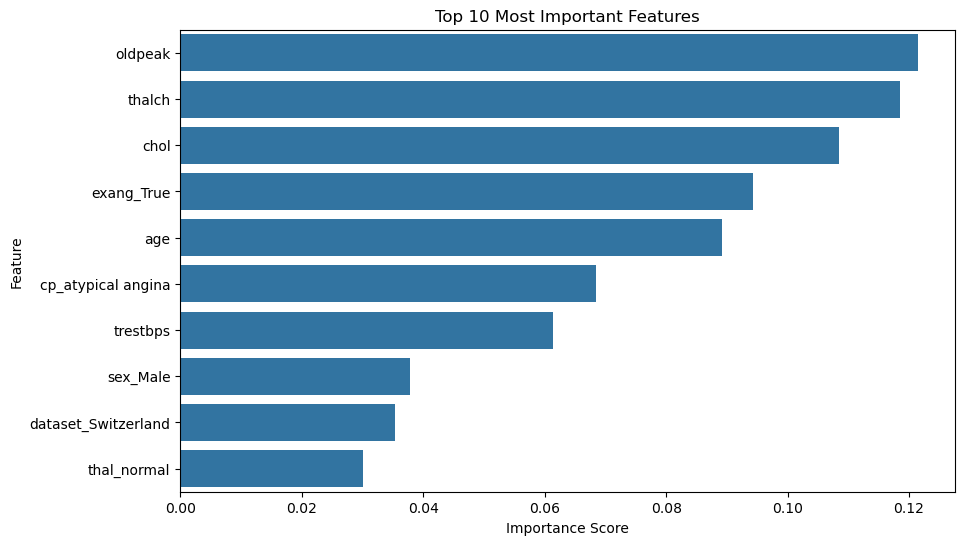

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

In [54]:
joblib.dump(best_rf, "rf_model.pkl")
joblib.dump(num_imputer, "numeric_imputer.pkl")
joblib.dump(cat_imputer, "categorical_imputer.pkl")
joblib.dump(X_train.columns.tolist(), "columns.pkl")

['columns.pkl']

In [56]:
print(best_rf)
print(X_train.shape)

RandomForestClassifier(max_depth=10, n_estimators=300, random_state=2026)
(644, 27)
